In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


exam_scores = pd.read_csv('data/exam_scores.csv')
df_encoded = pd.read_csv('data/student_preprocessed.csv')
X_scaled = pd.read_csv('data/X_scaled.csv')
X_pca_2d = pd.read_csv('data/X_pca_2d.csv')
X_pca_3d = pd.read_csv('data/X_pca_3d.csv')

exam_scores.head()

,Exam_Score
0,67
1,61
2,74
3,71
4,70



Cluster distribution for k=2:
1    3969
0    2638
Name: Cluster, dtype: int64


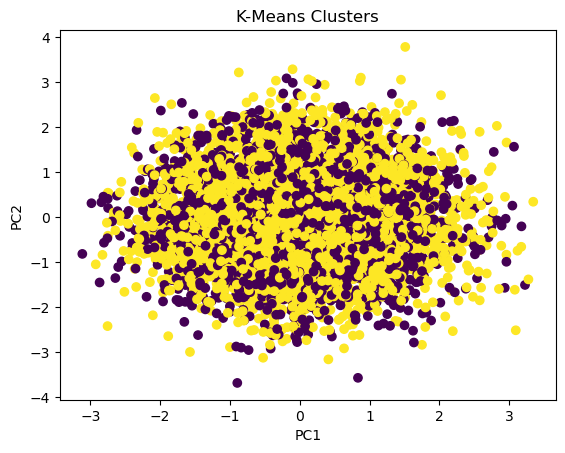


Cluster distribution for k=3:
1    2638
0    2592
2    1377
Name: Cluster, dtype: int64


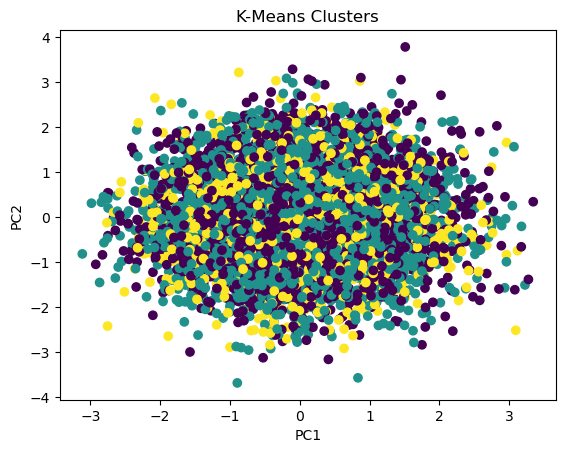


Cluster distribution for k=4:
1    2374
3    2313
2    1225
0     695
Name: Cluster, dtype: int64


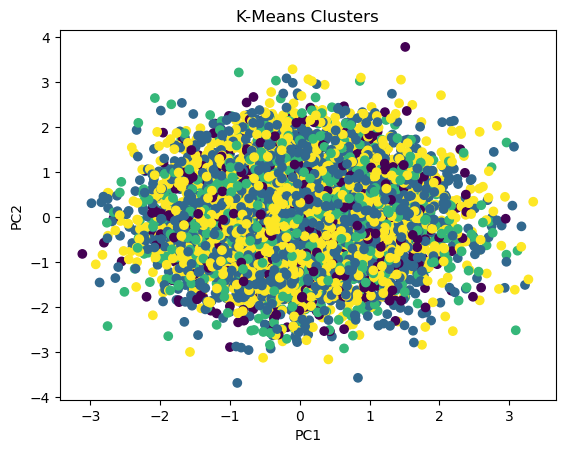


Cluster distribution for k=5:
1    2180
4    2144
3    1138
2     646
0     499
Name: Cluster, dtype: int64


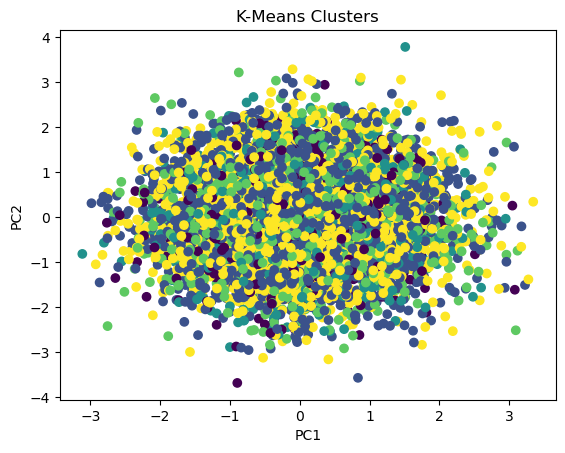

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

for k in [2, 3, 4, 5]:
    
    kmeans_model = KMeans(n_clusters=k, random_state = 42, n_init=10)

    kmeans_label = kmeans_model.fit_predict(X_scaled)

    df_encoded['Cluster'] = kmeans_label
    
    print(f"\nCluster distribution for k={k}:")
    print(df_encoded['Cluster'].value_counts())
    
    plt.scatter(X_pca_2d.iloc[:,0], X_pca_2d.iloc[:,1], c=kmeans_label)
    plt.title("K-Means Clusters")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()


Cluster distribution for k=2:
1    3969
0    2638
Name: Cluster, dtype: int64


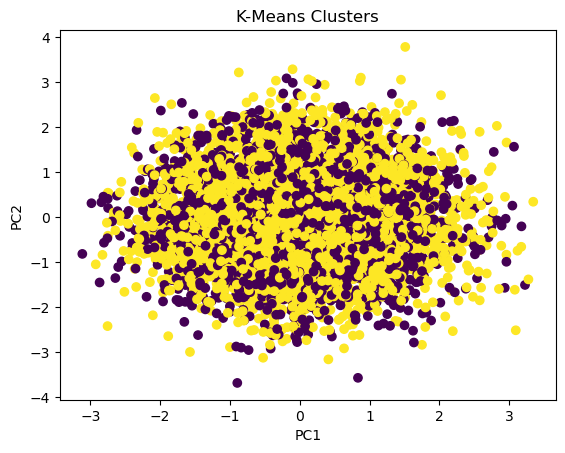


Cluster distribution for k=3:
1    2638
0    2592
2    1377
Name: Cluster, dtype: int64


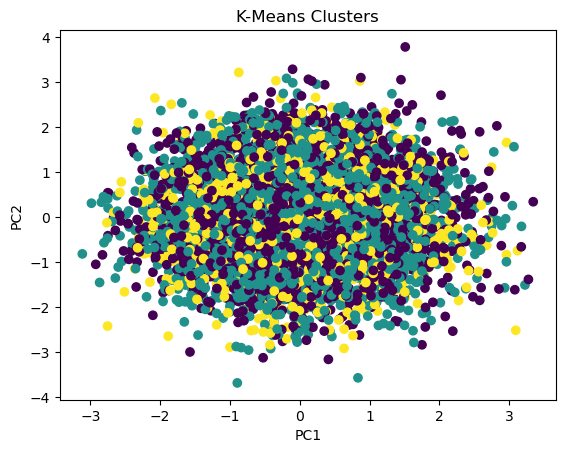


Cluster distribution for k=4:
1    2374
3    2313
2    1225
0     695
Name: Cluster, dtype: int64


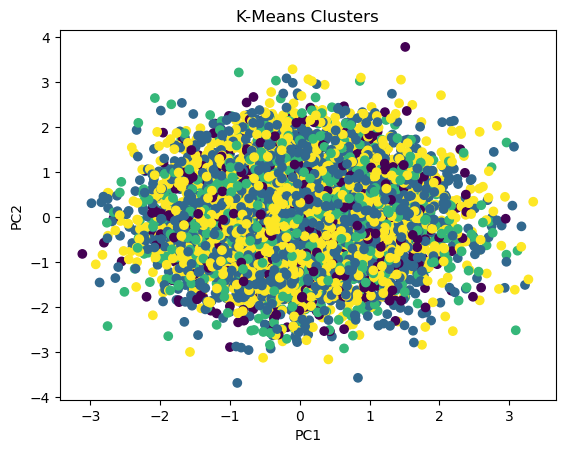


Cluster distribution for k=5:
1    2180
4    2144
3    1138
2     646
0     499
Name: Cluster, dtype: int64


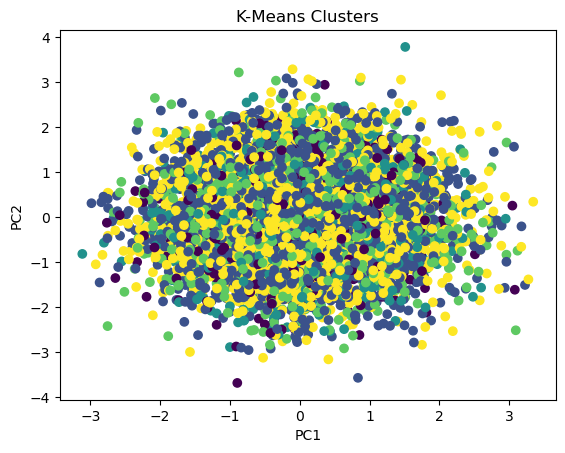

In [3]:
for k in [2, 3, 4, 5]:
    
    kmeans_model = KMeans(n_clusters=k, random_state = 42, n_init=10)

    kmeans_label = kmeans_model.fit_predict(X_scaled)

    df_encoded['Cluster'] = kmeans_label
    
    print(f"\nCluster distribution for k={k}:")
    print(df_encoded['Cluster'].value_counts())
    
    plt.scatter(X_pca_3d.iloc[:,0], X_pca_3d.iloc[:,1], c=kmeans_label)
    plt.title("K-Means Clusters")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [4]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import f_oneway

for k in [2,3,4,5]:
    
    kmeans_model = KMeans(n_clusters=k, random_state = 42, n_init=10)
    kmeans_label = kmeans_model.fit_predict(X_scaled)
    
    sil= silhouette_score(X_scaled, kmeans_label) 
    db = davies_bouldin_score(X_scaled, kmeans_label) 
    ch = calinski_harabasz_score(X_scaled, kmeans_label)
    
    #inertia = kmeans_model.inertia_ 
    
    n_clusters = len(np.unique(kmeans_label))
    df_encoded['Cluster'] = kmeans_label
    df_encoded['Exam_Score'] = exam_scores
    
    groups = [group['Exam_Score'].values for name, group in df_encoded.groupby('Cluster')]
    
    f_stat, p_value = f_oneway(*groups)

    print(f"\n ===== k = {k} =====")
    print(f"Silhouette Score: {sil:.4f}") 
    print(f"Davies Bouldin Score: {db:.4f}") 
    print(f"Calinski Harabasz Score: {ch:.4f}") 
    #print(f"Inertia: {inertia:.4f}")
    print(f"n_clusters: {n_clusters}") 
    print(f"ANOVA F-statistics: {f_stat:.4f}" ) 
    print(f"ANOVA p-value: {p_value:.4f}") 


 ===== k = 2 =====
Silhouette Score: 0.0772
Davies Bouldin Score: 3.3381
Calinski Harabasz Score: 547.4624
n_clusters: 2
ANOVA F-statistics: 43.8570
ANOVA p-value: 0.0000

 ===== k = 3 =====
Silhouette Score: 0.1086
Davies Bouldin Score: 2.7988
Calinski Harabasz Score: 551.4989
n_clusters: 3
ANOVA F-statistics: 34.0521
ANOVA p-value: 0.0000

 ===== k = 4 =====
Silhouette Score: 0.1073
Davies Bouldin Score: 2.6316
Calinski Harabasz Score: 468.9612
n_clusters: 4
ANOVA F-statistics: 36.7234
ANOVA p-value: 0.0000

 ===== k = 5 =====
Silhouette Score: 0.1098
Davies Bouldin Score: 2.4570
Calinski Harabasz Score: 439.6647
n_clusters: 5
ANOVA F-statistics: 31.2562
ANOVA p-value: 0.0000


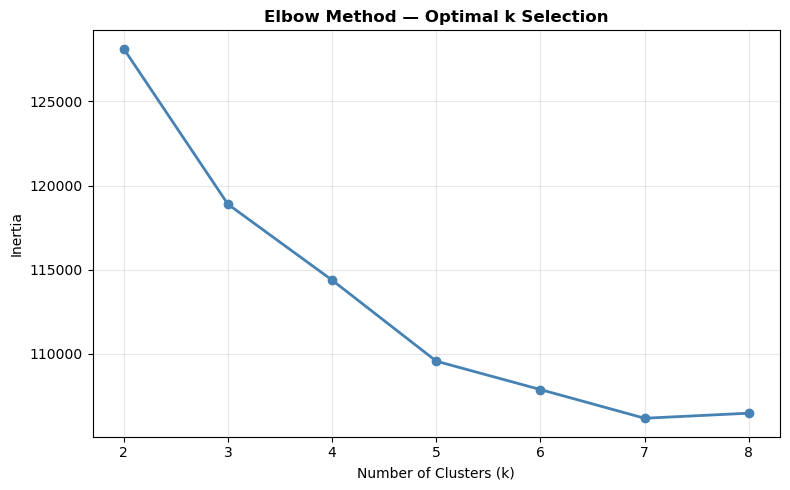

Elbow plot saved ✓


In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 9)

for k in k_range:
    kmm = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmm.fit(X_scaled)
    inertia.append(kmm.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k Selection', fontweight='bold')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Elbow plot saved ✓")

k=2 | Silhouette: 0.0772 | DB: 3.3381 | CH: 547.5
k=3 | Silhouette: 0.1098 | DB: 2.7988 | CH: 551.5
k=4 | Silhouette: 0.1086 | DB: 2.6316 | CH: 469.0
k=5 | Silhouette: 0.1102 | DB: 2.4570 | CH: 439.7
k=6 | Silhouette: 0.0805 | DB: 3.0146 | CH: 377.9
k=7 | Silhouette: 0.0600 | DB: 3.4230 | CH: 337.6
k=8 | Silhouette: 0.0585 | DB: 3.4908 | CH: 285.8


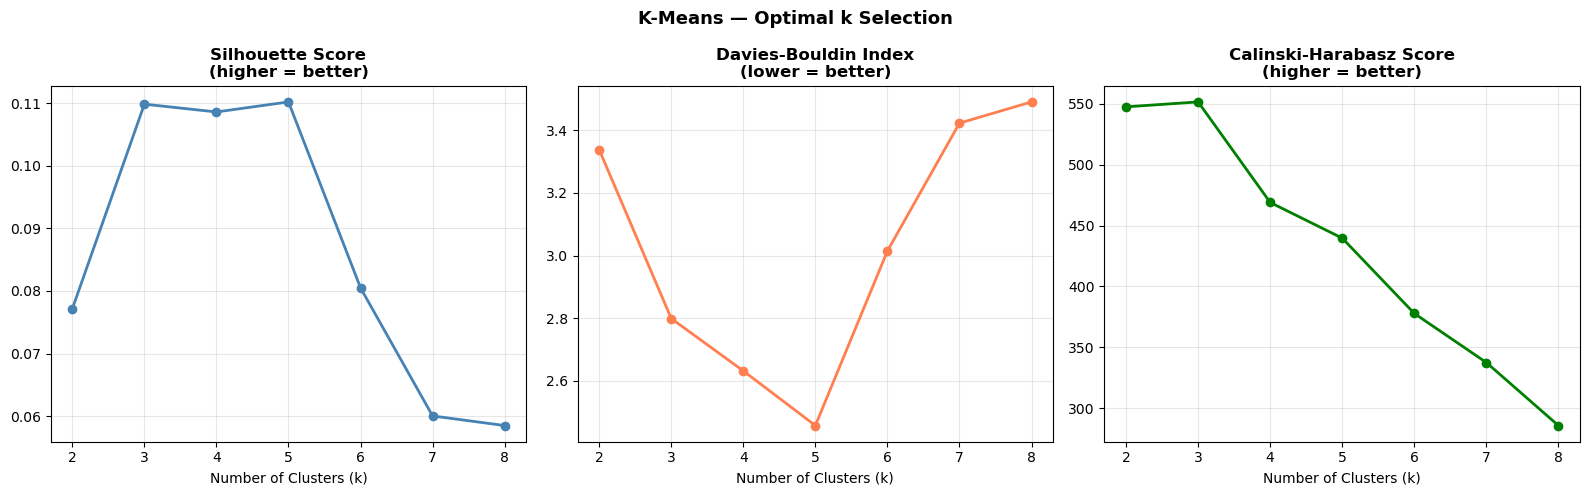

In [6]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_range = range(2, 9)
sil_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    kmm = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmm.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f"k={k} | Silhouette: {sil_scores[-1]:.4f} | DB: {db_scores[-1]:.4f} | CH: {ch_scores[-1]:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(k_range, sil_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score\n(higher = better)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, db_scores, marker='o', color='coral', linewidth=2)
axes[1].set_title('Davies-Bouldin Index\n(lower = better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

axes[2].plot(k_range, ch_scores, marker='o', color='green', linewidth=2)
axes[2].set_title('Calinski-Harabasz Score\n(higher = better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_xticks(list(k_range))
axes[2].grid(alpha=0.3)

plt.suptitle('K-Means — Optimal k Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import os
os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

OPTIMAL_K = 5  # justified by elbow + metric plots above

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(f"Final model: K-Means, k={OPTIMAL_K} ✓")
print(f"Inertia: {kmeans_final.inertia_:.2f}")
print(f"\nCluster distribution:")
dist = pd.Series(cluster_labels).value_counts().sort_index()
print(dist)
print(f"\nSmallest cluster: {dist.min()} students")
print(f"Largest cluster:  {dist.max()} students")
print(f"Imbalance ratio:  {dist.max()/dist.min():.1f}x")

Final model: K-Means, k=5 ✓
Inertia: 109561.66

Cluster distribution:
0     499
1    2180
2     646
3    1138
4    2144
dtype: int64

Smallest cluster: 499 students
Largest cluster:  2180 students
Imbalance ratio:  4.4x


In [8]:
from scipy.stats import f_oneway

sil_final = silhouette_score(X_scaled, cluster_labels, sample_size=2000, random_state=42)
db_final  = davies_bouldin_score(X_scaled, cluster_labels)
ch_final  = calinski_harabasz_score(X_scaled, cluster_labels)
inertia_final = kmeans_final.inertia_

df_encoded['Cluster'] = cluster_labels
df_encoded['Exam_Score'] = exam_scores.squeeze()
groups = [group['Exam_Score'].values for name, group in df_encoded.groupby('Cluster')]
f_stat, p_value = f_oneway(*groups)

print("=== FINAL MODEL EVALUATION ===")
print(f"Number of clusters:      {OPTIMAL_K}")
print(f"Silhouette Score:        {sil_final:.4f}  (higher is better)")
print(f"Davies-Bouldin Index:    {db_final:.4f}  (lower is better)")
print(f"Calinski-Harabasz Score: {ch_final:.1f}  (higher is better)")
print(f"Inertia:                 {inertia_final:.2f}  (lower is better)")
print(f"ANOVA F-statistic:       {f_stat:.4f}")
print(f"ANOVA p-value:           {p_value:.6f}")

metrics = {
    'Model': 'K-Means',
    'n_clusters': OPTIMAL_K,
    'Silhouette Score': round(sil_final, 4),
    'Davies-Bouldin Index': round(db_final, 4),
    'Calinski-Harabasz Score': round(ch_final, 1),
    'Inertia': round(inertia_final, 2),
    'ANOVA F-statistic': round(f_stat, 4),
    'ANOVA p-value': round(p_value, 6)
}
pd.DataFrame([metrics]).to_csv('data/metrics_kmeans.csv', index=False)
print("\nMetrics saved to data/metrics_kmeans.csv ✓")

=== FINAL MODEL EVALUATION ===
Number of clusters:      5
Silhouette Score:        0.1102  (higher is better)
Davies-Bouldin Index:    2.4570  (lower is better)
Calinski-Harabasz Score: 439.7  (higher is better)
Inertia:                 109561.66  (lower is better)
ANOVA F-statistic:       31.2562
ANOVA p-value:           0.000000

Metrics saved to data/metrics_kmeans.csv ✓


In [ ]:
palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

results_df = X_scaled.copy()
results_df['Cluster'] = cluster_labels
results_df['PC1'] = X_pca_2d['PC1'].values
results_df['PC2'] = X_pca_2d['PC2'].values

plt.figure(figsize=(9, 6))
for cluster_id in sorted(results_df['Cluster'].unique()):
    mask = results_df['Cluster'] == cluster_id
    plt.scatter(
        results_df.loc[mask, 'PC1'],
        results_df.loc[mask, 'PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.4, s=12,
        color=palette[cluster_id]
    )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering (k={OPTIMAL_K}) — PCA 2D', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/kmeans_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.manifold import TSNE

np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=2000, replace=False)
X_sample = np.array(X_scaled)[sample_idx]
labels_sample = cluster_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(9, 6))
for cluster_id in sorted(np.unique(labels_sample)):
    mask = labels_sample == cluster_id
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=f'Cluster {cluster_id}',
                alpha=0.5, s=15,
                color=palette[cluster_id])

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualisation — K-Means Clusters (n=2000 sample)',
          fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig('plots/kmeans_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import seaborn as sns

profile_cols = [
    'Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score',
    'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity',
    'Motivation_Level', 'Access_to_Resources', 'Parental_Involvement',
    'Family_Income', 'Learning_Disabilities'
]

df_encoded['Cluster'] = cluster_labels
profile = df_encoded.groupby('Cluster')[profile_cols].mean().round(2)

print("=== CLUSTER PROFILES ===")
print(profile.T)

# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(profile.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title(f'Cluster Profile Heatmap (K-Means, k={OPTIMAL_K})',
          fontweight='bold', fontsize=13)
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('plots/kmeans_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Exam score bar chart
exam_by_cluster = df_encoded.groupby('Cluster')['Exam_Score'].mean()
plt.figure(figsize=(7, 5))
plt.bar(exam_by_cluster.index, exam_by_cluster.values,
        color=[palette[i] for i in exam_by_cluster.index], edgecolor='white')
plt.xlabel('Cluster')
plt.ylabel('Mean Exam Score')
plt.title('Mean Exam Score by Cluster (K-Means)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/kmeans_exam_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# Learning disabilities check
print("\n=== LEARNING DISABILITIES PER CLUSTER ===")
print(df_encoded.groupby('Cluster')['Learning_Disabilities'].mean().round(3))
print(df_encoded.groupby('Cluster').size())

In [ ]:
plt.figure(figsize=(7, 7))
sizes = pd.Series(cluster_labels).value_counts().sort_index()
plt.pie(sizes.values,
        labels=[f'Cluster {i}' for i in sizes.index],
        autopct='%1.1f%%',
        colors=palette[:len(sizes)],
        startangle=140)
plt.title('K-Means Cluster Size Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/kmeans_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
radar_cols = ['Hours_Studied', 'Attendance', 'Motivation_Level',
              'Access_to_Resources', 'Sleep_Hours', 'Tutoring_Sessions']

profile_radar = df_encoded.groupby('Cluster')[radar_cols].mean()
profile_norm = (profile_radar - profile_radar.min()) / (profile_radar.max() - profile_radar.min())

angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(20, 4), subplot_kw=dict(polar=True))

for ax, (cluster_id, row) in zip(axes, profile_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, color=palette[cluster_id])
    ax.fill(angles, values, alpha=0.25, color=palette[cluster_id])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_cols, size=7)
    ax.set_title(f'Cluster {cluster_id}', size=9, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('K-Means Cluster Radar Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/kmeans_radar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_scaled, cluster_labels)

importances = pd.Series(dt.feature_importances_,
                        index=X_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Features — K-Means Cluster Separation\n(Decision Tree Proxy)',
          fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/kmeans_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(importances.head())
importances.to_csv('data/kmeans_feature_importance.csv', header=['Importance'])

accuracy = accuracy_score(cluster_labels, dt.predict(X_scaled))
print(f"\nDecision Tree reproduced {accuracy*100:.1f}% of K-Means assignments")

In [ ]:
cluster_names_kmeans = {
    0: 'At-Risk Borderline Group',
    1: 'General Students B',
    2: 'Students with Learning Disabilities',
    3: 'General Students C',
    4: 'General Students A'
}
# Update based on actual Learning_Disabilities output above

df_encoded['Cluster_Label'] = df_encoded['Cluster'].map(cluster_names_kmeans)

print("Cluster label distribution:")
print(df_encoded['Cluster_Label'].value_counts())

print("\nMean Exam Score per Cluster:")
print(df_encoded.groupby('Cluster_Label')['Exam_Score'].mean().round(2).sort_values())

df_encoded.to_csv('data/kmeans_labelled.csv', index=False)
print("\nLabelled dataset saved ✓")

In [ ]:
print("=" * 55)
print("K-MEANS CLUSTERING — FINAL SUMMARY")
print("=" * 55)
print(f"Algorithm:         K-Means")
print(f"Optimal k:         {OPTIMAL_K}")
print(f"Silhouette Score:  {sil_final:.4f}")
print(f"Davies-Bouldin:    {db_final:.4f}")
print(f"Calinski-Harabasz: {ch_final:.1f}")
print(f"Inertia:           {inertia_final:.2f}")
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value:     p < 0.001")
print(f"\nMetrics saved: data/metrics_kmeans.csv")
print("=" * 55)